In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt

NAME = "Usama Afzal"
ROLL_NUMBER = "01-136232-074"
SEED = 136232074

random.seed(SEED)
np.random.seed(SEED)

print("Name:", NAME)
print("Roll Number:", ROLL_NUMBER)
print("Seed:", SEED)

Name: Usama Afzal
Roll Number: 01-136232-074
Seed: 136232074


In [2]:
GRID_SIZE = 20
OBSTACLE_PERCENTAGE = 20

grid = np.zeros((GRID_SIZE, GRID_SIZE), dtype=int)

num_cells = GRID_SIZE * GRID_SIZE
num_obstacles = int(num_cells * OBSTACLE_PERCENTAGE / 100)

all_cells = [(x, y) for x in range(GRID_SIZE)
             for y in range(GRID_SIZE)]

obstacle_cells = random.sample(all_cells, num_obstacles)

for x, y in obstacle_cells:
    grid[x, y] = 1

print("Grid size:", GRID_SIZE, "x", GRID_SIZE)
print("Number of obstacles:", num_obstacles)

Grid size: 20 x 20
Number of obstacles: 80


In [3]:
free_cells = [(x, y) for x in range(GRID_SIZE)
              for y in range(GRID_SIZE)
              if grid[x, y] == 0]

start, goal = random.sample(free_cells, 2)

print("Start:", start)
print("Goal:", goal)

Start: (19, 5)
Goal: (13, 17)


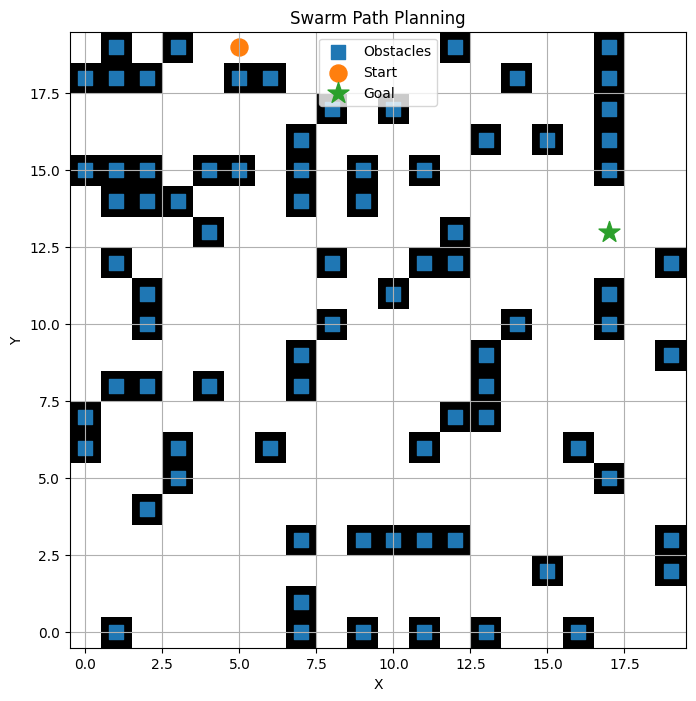

In [4]:
plt.figure(figsize=(8, 8))

plt.imshow(grid, cmap="gray_r", origin="lower")

obstacle_x = [x for x, y in obstacle_cells]
obstacle_y = [y for x, y in obstacle_cells]

plt.scatter(obstacle_y, obstacle_x, marker="s", s=100, label="Obstacles")
plt.scatter(start[1], start[0], marker="o", s=150, label="Start")
plt.scatter(goal[1], goal[0], marker="*", s=250, label="Goal")

plt.title("Swarm Path Planning")
plt.xlabel("X")
plt.ylabel("Y")
plt.grid(True)
plt.legend()
plt.show()

In [6]:
NUM_PARTICLES = 40
MAX_ITERATIONS = 150

W = 0.7
C1 = 1.5
C2 = 1.5

DIRECTIONS = [
    (-1, -1), (-1, 0), (-1, 1),
    (0, -1),           (0, 1),
    (1, -1),  (1, 0),  (1, 1)
]

def valid_move(position):
    x, y = position

    if x < 0 or x >= GRID_SIZE or y < 0 or y >= GRID_SIZE:
        return False

    if grid[x, y] == 1:
        return False

    return True


def generate_path():
    current = start
    path = [current]

    for _ in range(GRID_SIZE * GRID_SIZE):
        if current == goal:
            break

        possible_moves = []

        for dx, dy in DIRECTIONS:
            next_position = (current[0] + dx, current[1] + dy)

            if valid_move(next_position):
                possible_moves.append(next_position)

        if not possible_moves:
            break

        next_position = min(
            possible_moves,
            key=lambda p: abs(p[0] - goal[0]) + abs(p[1] - goal[1])
        )

        if next_position in path:
            break

        path.append(next_position)
        current = next_position

    return path

In [7]:
NUM_PARTICLES = 100
PATH_LENGTH = 50
MAX_ITERATIONS = 200

W = 0.7
C1 = 1.5
C2 = 1.7

DIRECTIONS = np.array([
    (-1, -1), (-1, 0), (-1, 1),
    (0, -1),           (0, 1),
    (1, -1),  (1, 0),  (1, 1)
])

def evaluate(position):
    current = start
    path = [current]
    invalid = 0

    for value in position:
        dx, dy = DIRECTIONS[int(np.clip(round(value), 0, 7))]
        nxt = (current[0] + dx, current[1] + dy)

        if (0 <= nxt[0] < GRID_SIZE and
            0 <= nxt[1] < GRID_SIZE and
            grid[nxt] == 0):
            current = nxt
            path.append(current)
        else:
            invalid += 1

    distance = np.hypot(current[0] - goal[0], current[1] - goal[1])

    length = sum(
        np.hypot(b[0] - a[0], b[1] - a[1])
        for a, b in zip(path[:-1], path[1:])
    )

    cost = distance * 20 + length + invalid * 100

    if current == goal:
        cost -= 1000

    return cost, path, invalid


np.random.seed(SEED)

particles = np.random.uniform(
    0, 7, (NUM_PARTICLES, PATH_LENGTH)
)

velocities = np.random.uniform(
    -1, 1, (NUM_PARTICLES, PATH_LENGTH)
)

pbest = particles.copy()
pbest_cost = np.array([
    evaluate(p)[0] for p in particles
])

best_idx = np.argmin(pbest_cost)
gbest = pbest[best_idx].copy()
gbest_cost = pbest_cost[best_idx]

history = []

for _ in range(MAX_ITERATIONS):

    r1 = np.random.rand(NUM_PARTICLES, PATH_LENGTH)
    r2 = np.random.rand(NUM_PARTICLES, PATH_LENGTH)

    velocities = (
        W * velocities
        + C1 * r1 * (pbest - particles)
        + C2 * r2 * (gbest - particles)
    )

    velocities = np.clip(velocities, -2, 2)
    particles = np.clip(particles + velocities, 0, 7)

    costs = np.array([
        evaluate(p)[0] for p in particles
    ])

    better = costs < pbest_cost

    pbest[better] = particles[better]
    pbest_cost[better] = costs[better]

    idx = np.argmin(pbest_cost)

    if pbest_cost[idx] < gbest_cost:
        gbest = pbest[idx].copy()
        gbest_cost = pbest_cost[idx]

    history.append(gbest_cost)

best_cost, best_path, invalid = evaluate(gbest)

print("Best Cost:", round(best_cost, 2))
print("Path Length:", len(best_path))
print("Invalid Moves:", invalid)
print("Start:", best_path[0])
print("Final Position:", best_path[-1])
print("Goal:", goal)

Best Cost: -945.86
Path Length: 51
Invalid Moves: 0
Start: (19, 5)
Final Position: (np.int64(13), np.int64(17))
Goal: (13, 17)


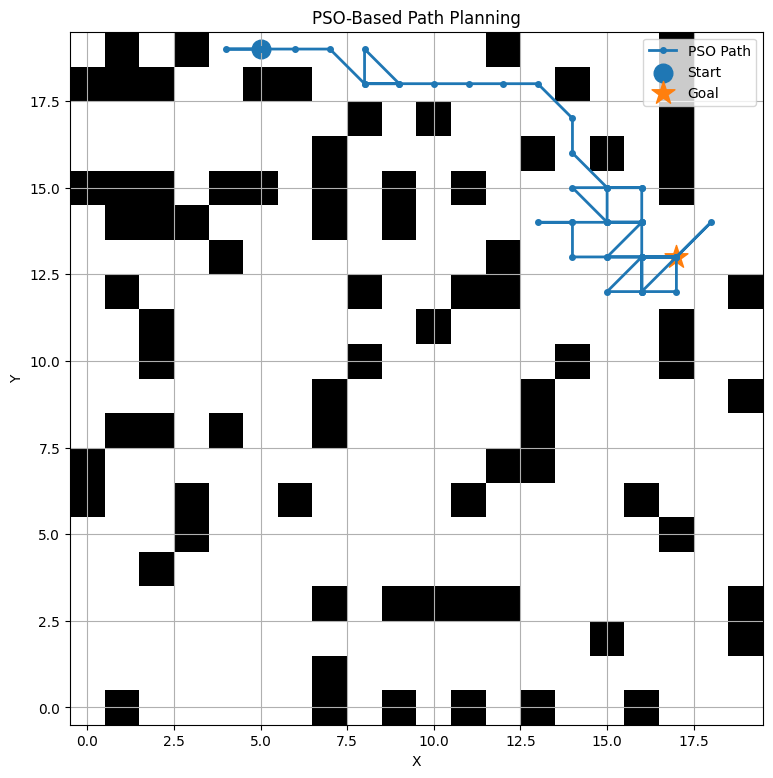

Best Cost: -945.86
Number of Positions: 51
Path Reaches Goal: True


In [8]:
path_x = [p[0] for p in best_path]
path_y = [p[1] for p in best_path]

plt.figure(figsize=(9, 9))

plt.imshow(grid, cmap="gray_r", origin="lower")

plt.plot(
    path_y,
    path_x,
    marker="o",
    linewidth=2,
    markersize=4,
    label="PSO Path"
)

plt.scatter(
    start[1],
    start[0],
    marker="o",
    s=180,
    label="Start"
)

plt.scatter(
    goal[1],
    goal[0],
    marker="*",
    s=300,
    label="Goal"
)

plt.title("PSO-Based Path Planning")
plt.xlabel("X")
plt.ylabel("Y")
plt.grid(True)
plt.legend()

plt.show()

print("Best Cost:", round(best_cost, 2))
print("Number of Positions:", len(best_path))
print("Path Reaches Goal:", best_path[-1] == goal)